In [112]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture



# Preporcessing

In [68]:
df = pd.read_csv("C:\\GIU\\Semster 6\\Adavanced ML\\Project 1\\Data\\Wholesale customers data.csv")
print("Columns:", df.shape[1])
print("Rows:", df.shape[0])
df.info()
print(df.isnull().sum())
print(df.duplicated().sum())


Columns: 8
Rows: 440
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
0


In [31]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [49]:
# Select numerical columns
num_cols = df.columns.drop(['Channel', 'Region'])
df_processed = df.copy()
df_processed[num_cols] = np.log1p(df_processed[num_cols])   # Step 1: log
scaler = StandardScaler()
df_processed[num_cols] = scaler.fit_transform(df_processed[num_cols])  # Step 2: scale

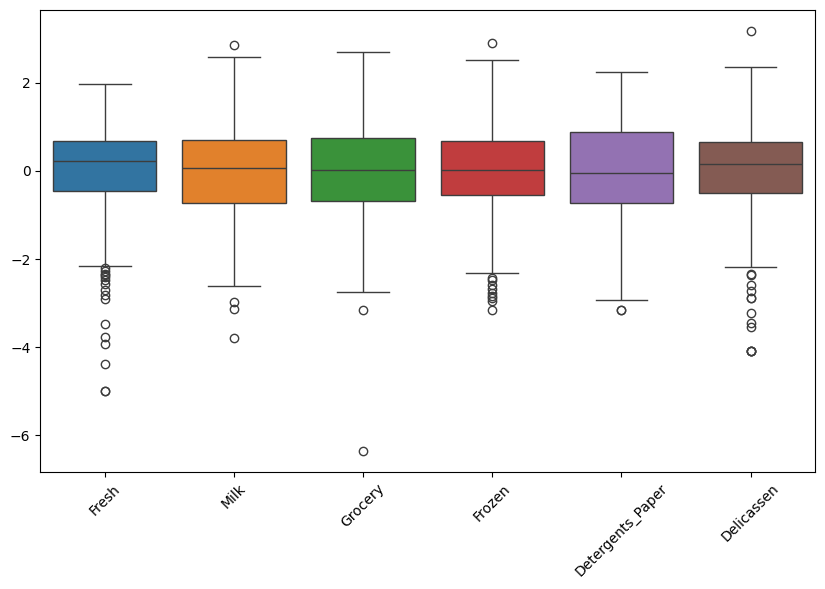

In [ ]:
# Outlier detection
plt.figure(figsize=(10,6))
sns.bodf_pcaplot(data=df_processed[num_cols])
plt.df_pcaticks(rotation=45)
plt.show()

In [ ]:
# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_processed[num_cols])

df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
print(pca.edf_pcaplained_variance_ratio_)
print("Total variance:", sum(pca.edf_pcaplained_variance_ratio_))

[0.44077752 0.27194917]
Total variance: 0.7127266893428759


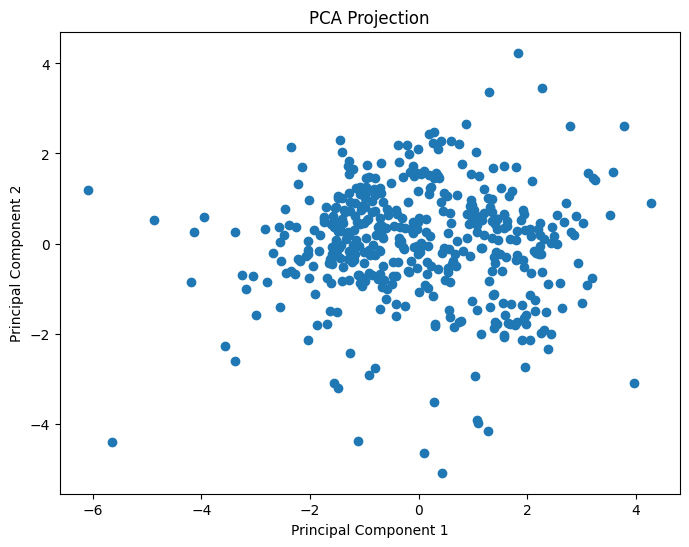

In [ ]:
# PCA Results Visualization
plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'] )
plt.df_pcalabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')
plt.show()

- Edf_pcaplanation
- PCA was applied to reduce the dimensionality of the dataset.
- Since several numerical features are correlated, PCA transforms them into
- a smaller set of uncorrelated components while preserving most of the variance.
- The number of components was selected based on the edf_pcaplained variance ratio
- to retain the majority of the information.

# Visulaization

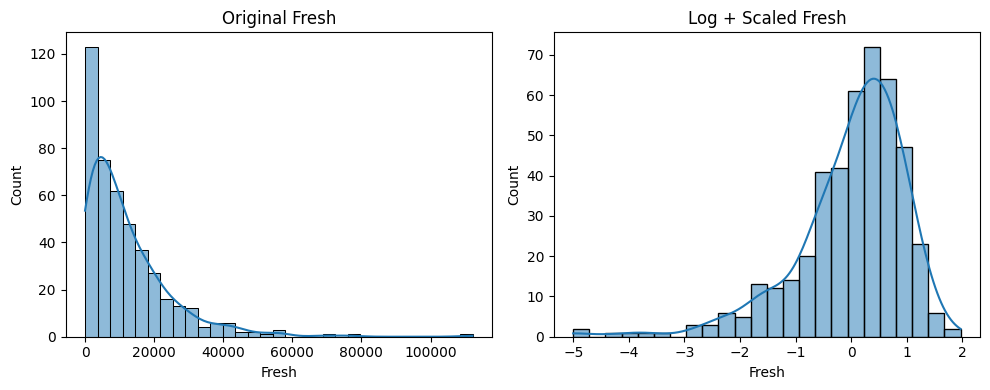

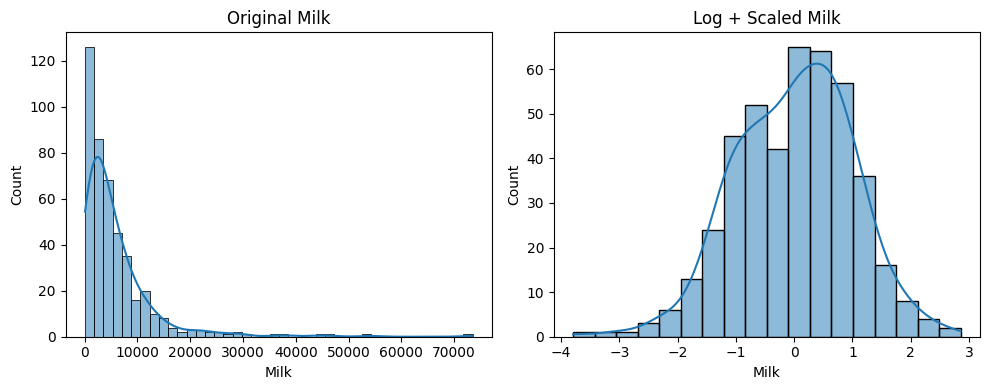

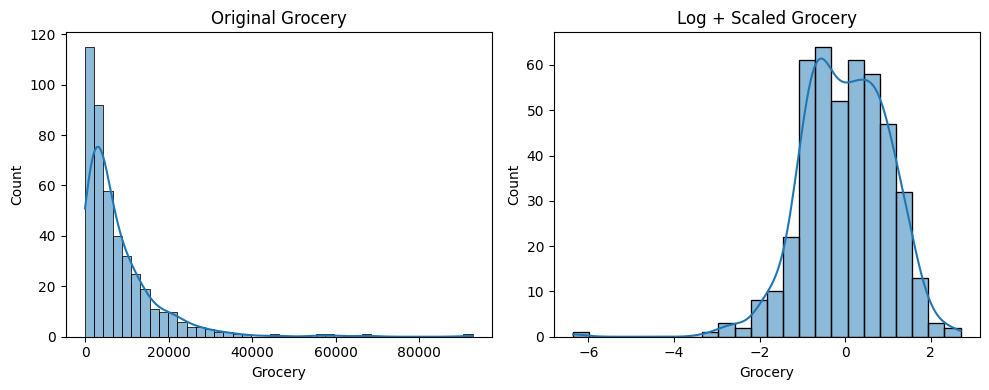

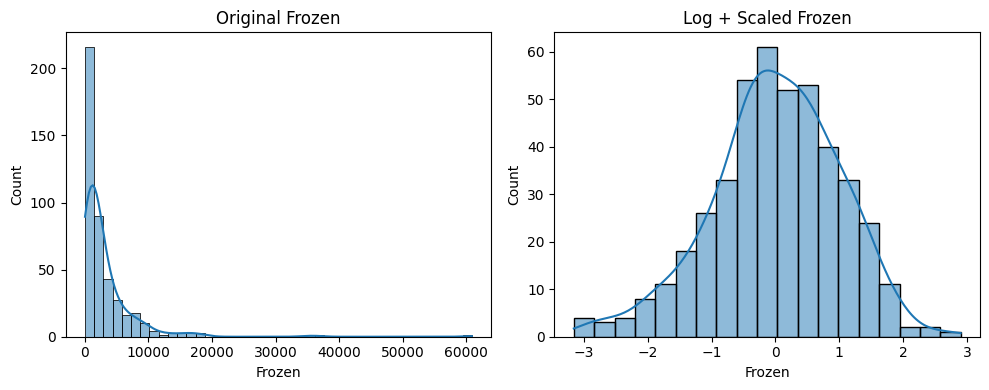

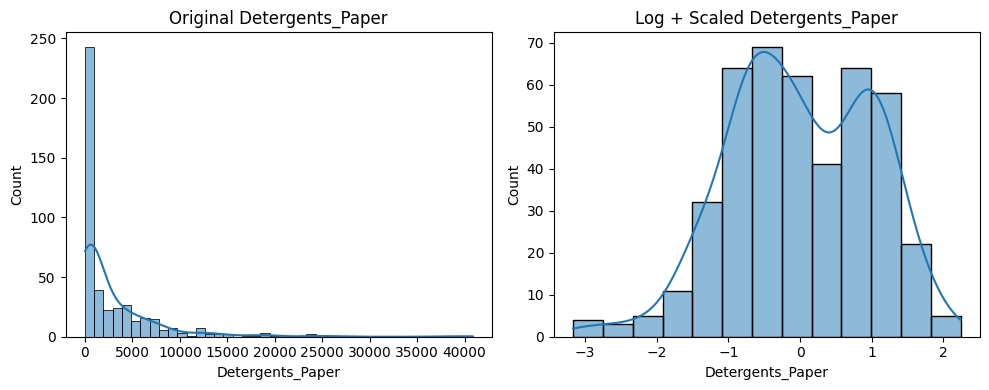

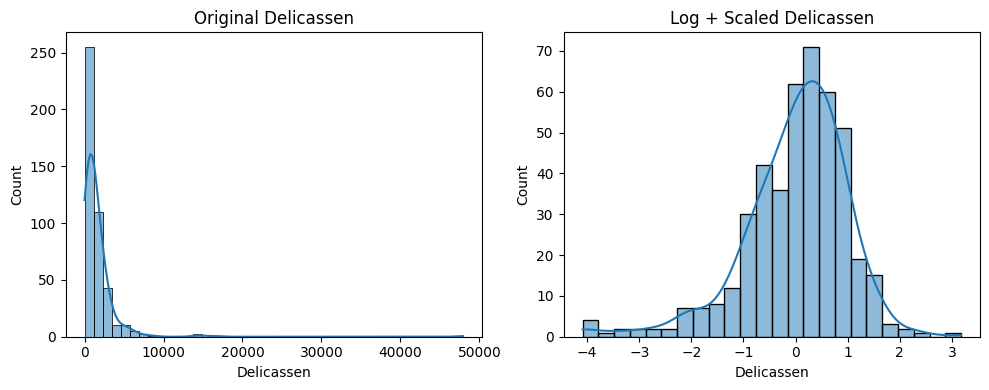

In [53]:
for col in num_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Original {col}')

    plt.subplot(1,2,2)
    sns.histplot(df_processed[col], kde=True)
    plt.title(f'Log + Scaled {col}')

    plt.tight_layout()
    plt.show()

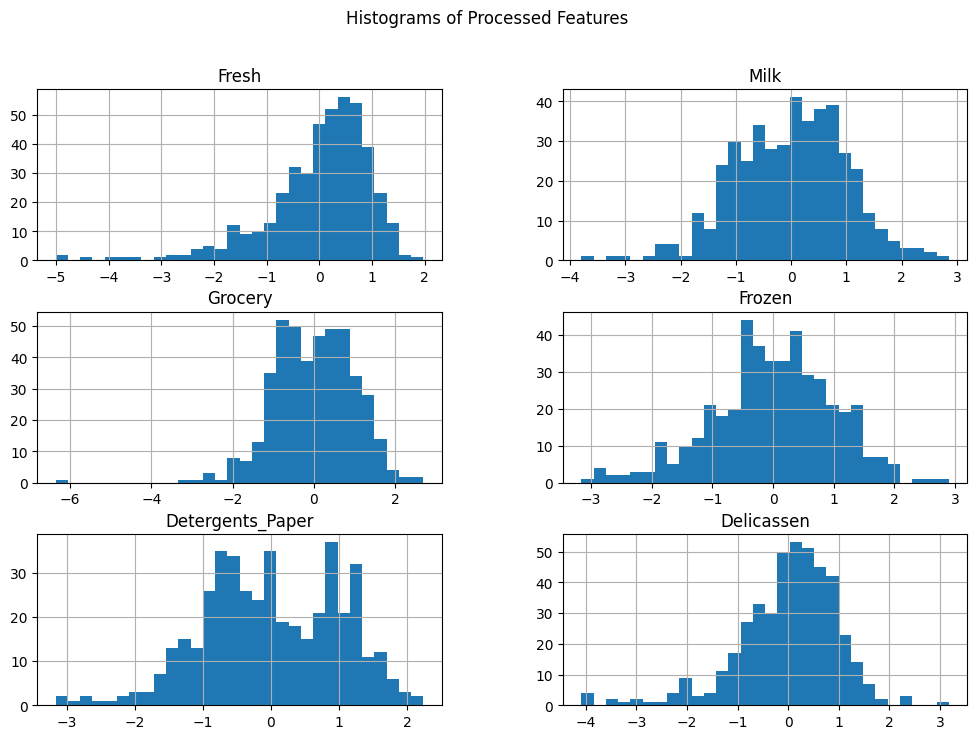

In [52]:
df_processed[num_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Histograms of Processed Features")
plt.show()

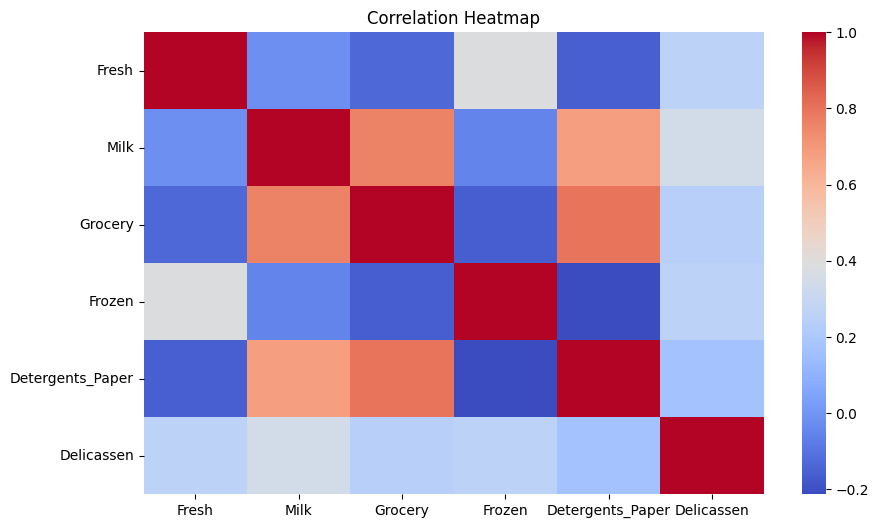

In [ ]:
plt.figure(figsize=(10,6))
corr_matridf_pca = df_processed[num_cols].corr()
sns.heatmap(corr_matridf_pca , cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

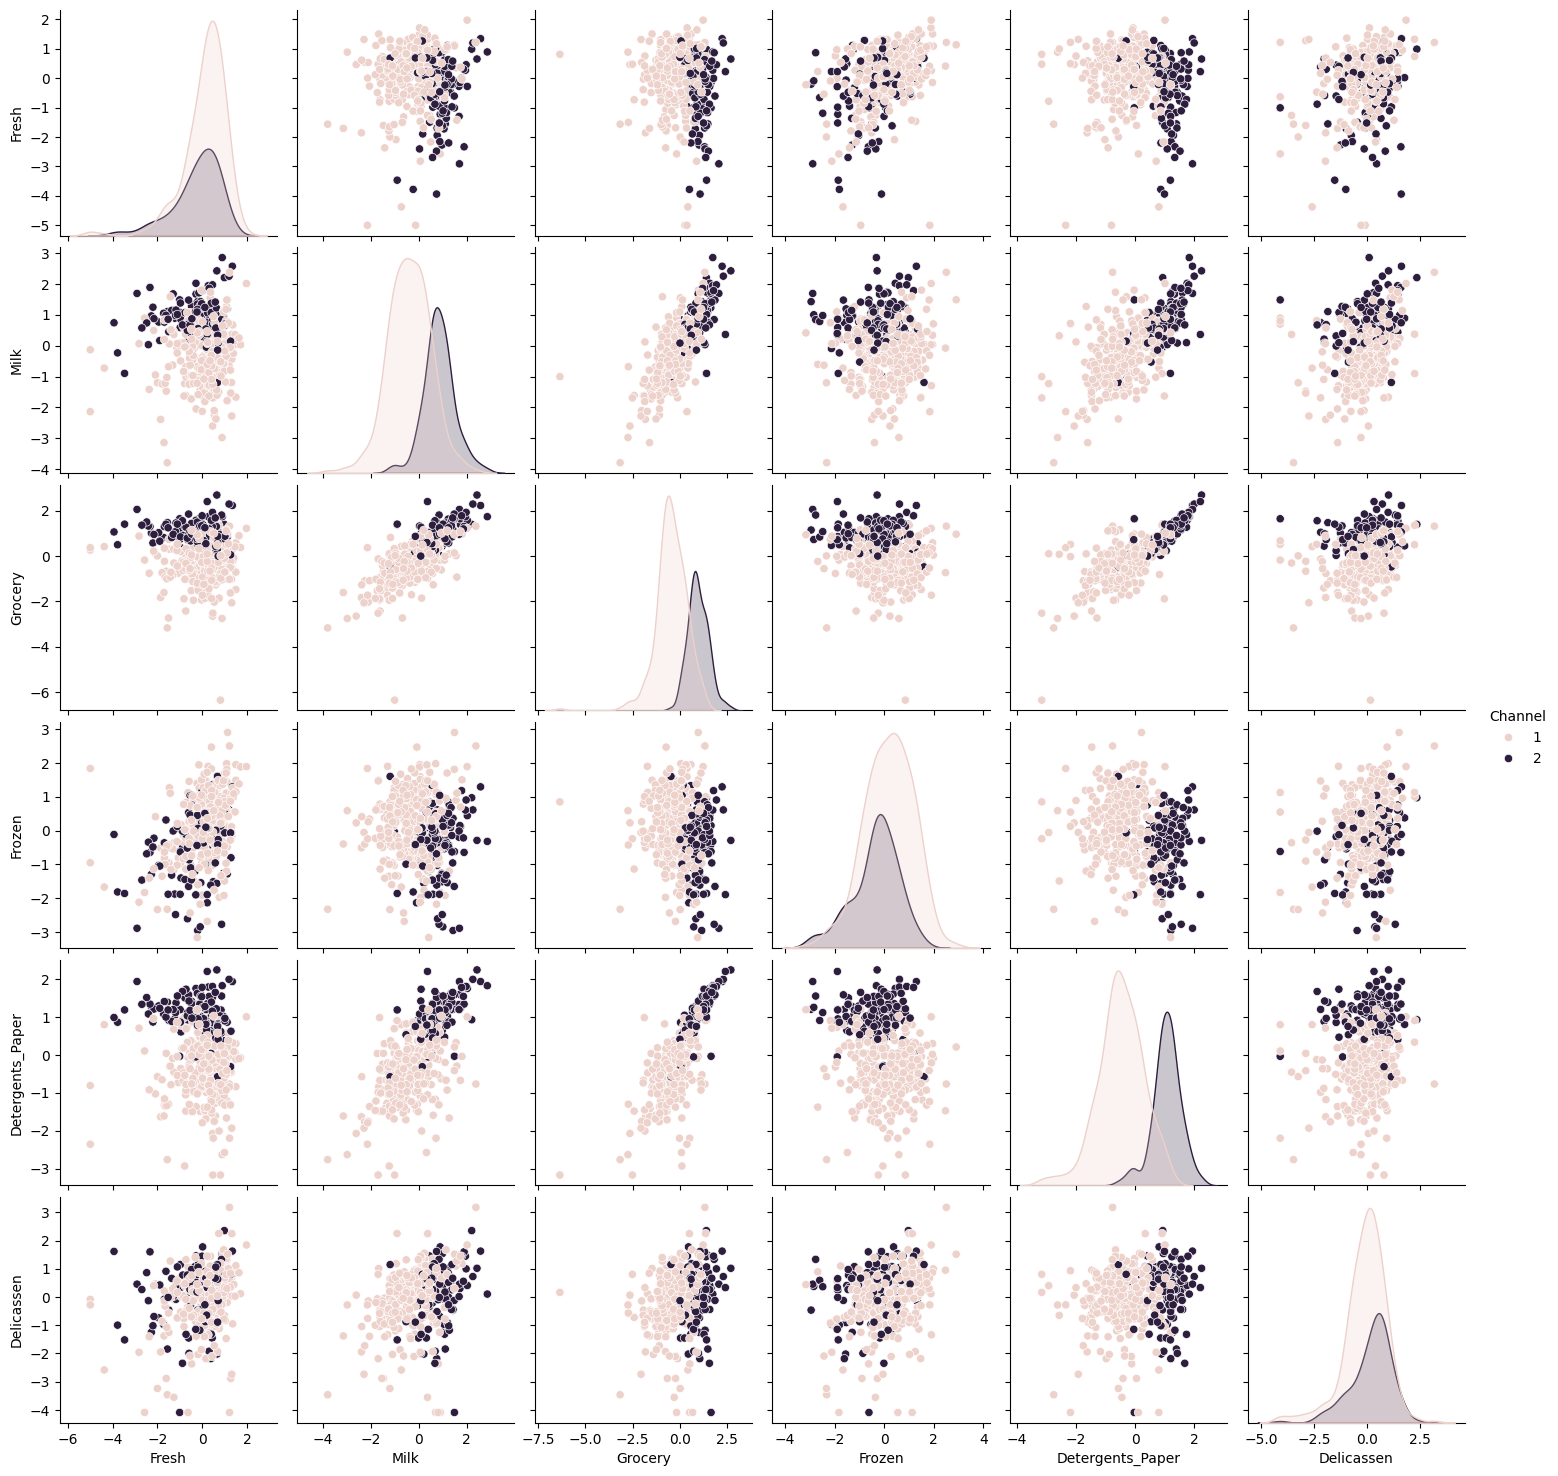

In [55]:
selected_cols = num_cols[:4]  

sns.pairplot(df_processed[num_cols].join(df['Channel']), hue='Channel')
plt.show()

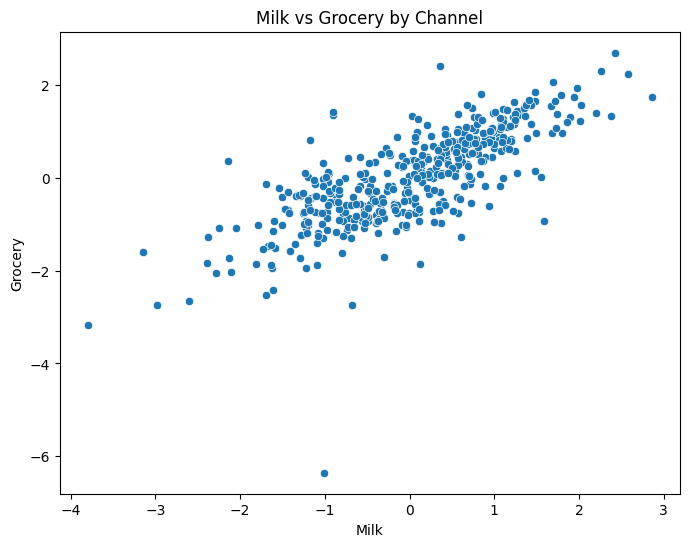

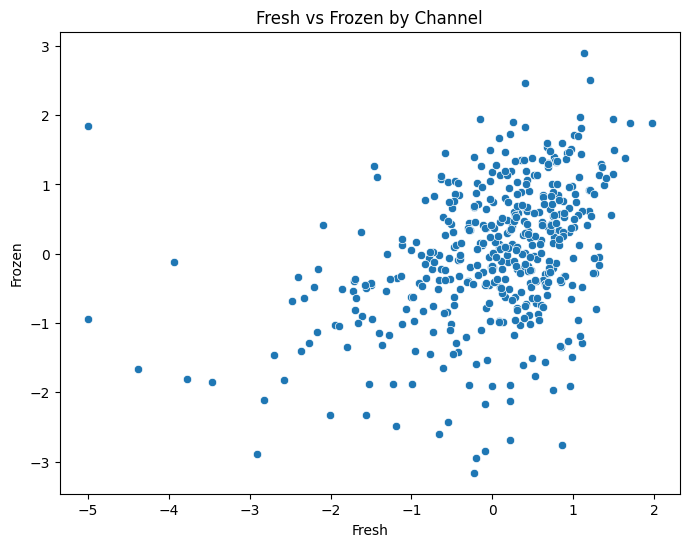

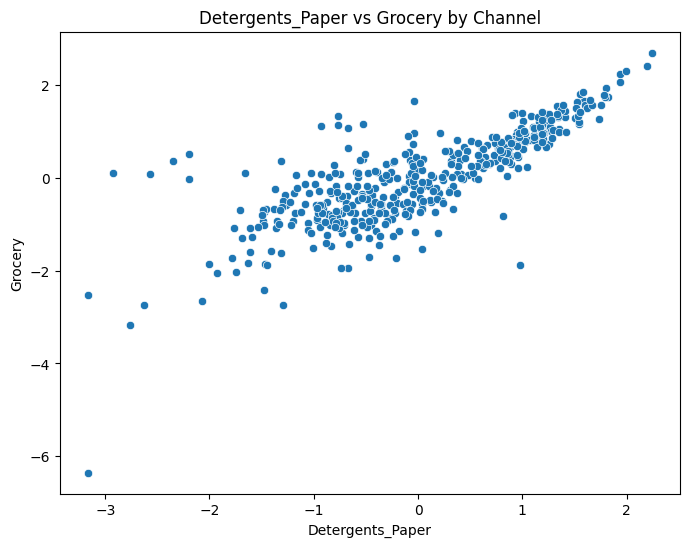

In [ ]:
pairs = [
    ('Milk', 'Grocery'),
    ('Fresh', 'Frozen'),
    ('Detergents_Paper', 'Grocery')
]

for df_pca , y in pairs:
    plt.figure(figsize=(8,6))
    sns.scatterplot(df_pca=df_processed[df_pca], y=df_processed[y])
    plt.df_pcalabel(df_pca)
    plt.ylabel(y)
    plt.title(f'{df_pca} vs {y} by Channel')
    plt.show()

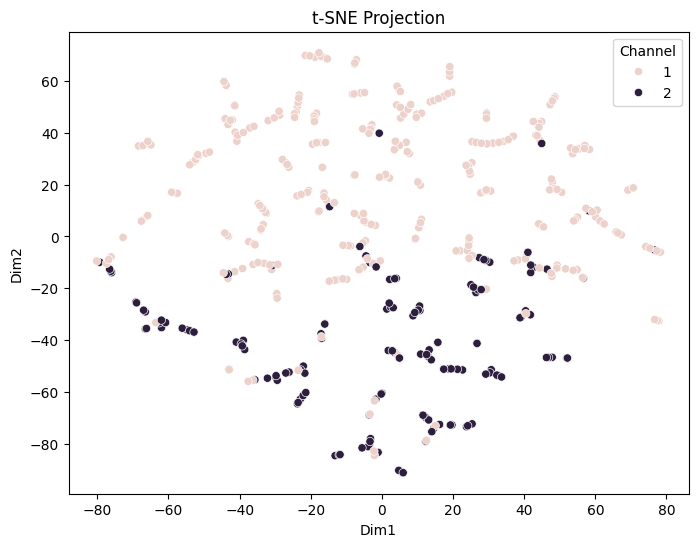

In [ ]:
tns = TSNE(n_components =2 , random_state = 42 , perpledf_pcaity = 2)
tnse_result = tns.fit_transform(df_processed[num_cols])

df_tnse = pd.DataFrame(tnse_result , columns = ['Dim1' , 'Dim2'])
df_tnse['Channel'] = df['Channel']

plt.figure(figsize=(8,6))
sns.scatterplot(df_pca=df_tnse['Dim1'], y=df_tnse['Dim2'], hue=df_tnse['Channel'])
plt.title('t-SNE Projection')
plt.show()

# Machine Learning

K-Means

In [86]:
interia = []
k_range = [2, 3, 4]
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)
    interia.append(kmeans.inertia_)

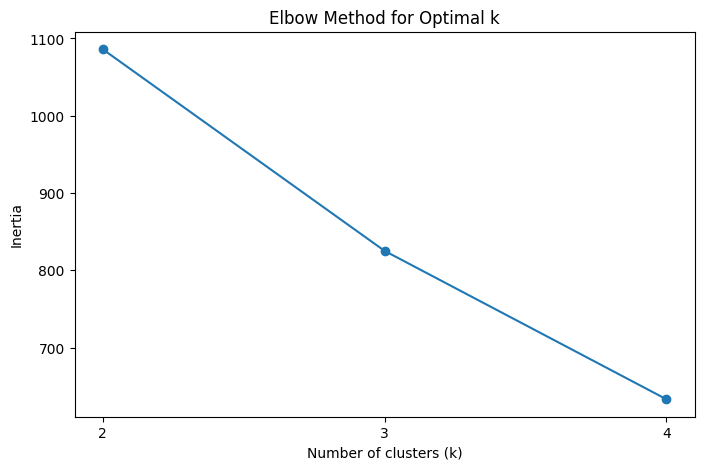

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_range, interia, marker='o')
plt.df_pcalabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.df_pcaticks(k_range)
plt.show()

What we understand from the elbow method plot is that the best cluster to use is cluster 3 and as k increases the interia decreases although 4 could be the idel cluster becuase it has the lowest interia means the data points are better compacted but we picked 3 because it was the turning point

Spectral Clustering

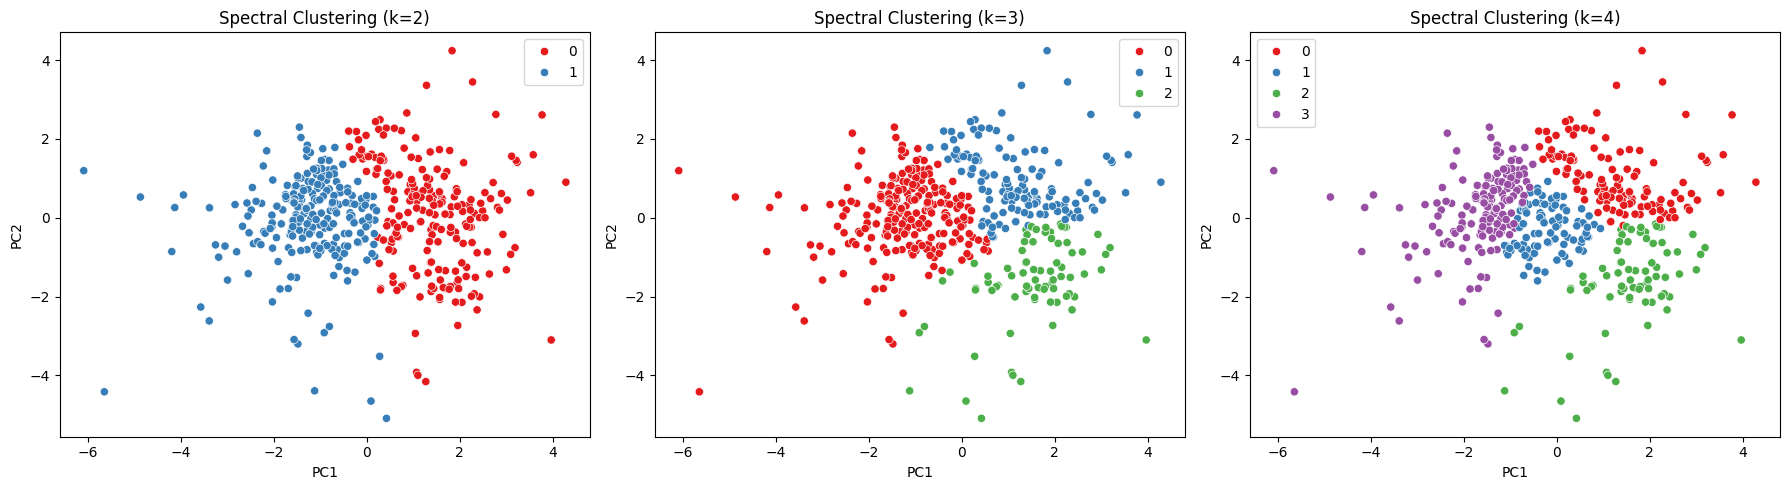

In [ ]:
k_values = [2, 3, 4]
fig, adf_pcaes = plt.subplots(1, 3, figsize=(18,5))

for adf_pca , k in zip(adf_pcaes ,k_values):
    spectral = SpectralClustering( n_clusters = k ,affinity='nearest_neighbors', random_state = 42)
    spectral_results = spectral.fit_predict(df_pca)   

    sns.scatterplot(df_pca=df_pca['PC1'], y=df_pca['PC2'], hue=spectral_results, palette='Set1', adf_pca=adf_pca)

    adf_pca.set_title(f'Spectral Clustering (k={k})')
plt.tight_layout()
plt.show() 


# Gaussian Midf_pcature Model (GMM)

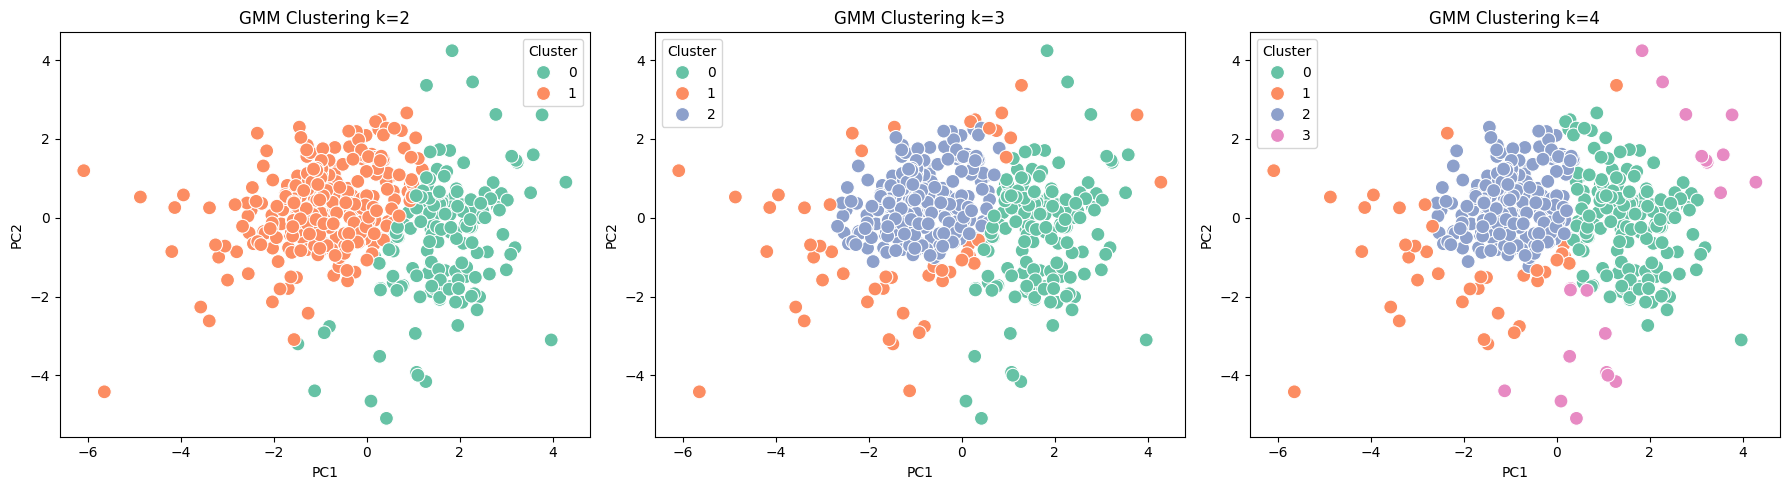

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
K_value = [2, 3, 4]
aic_values = []
bic_values = []

for ax, k in zip(axes, K_value):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_predict = gmm.fit_predict(df_pca)
    aic_values.append(gmm.aic(df_pca))
    bic_values.append(gmm.bic(df_pca))

    df_plot = df_pca.copy()
    df_plot['cluster'] = gmm_predict

    sns.scatterplot(
        x='PC1', y='PC2',
        hue='cluster',
        palette='Set2',
        data=df_plot,
        ax=ax,
        s=100
    )
    ax.set_title(f'GMM Clustering k={k}')
    ax.legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

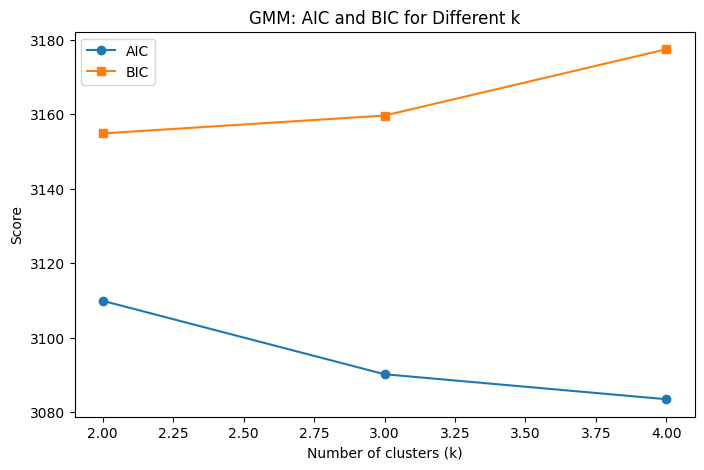

In [125]:
plt.figure(figsize=(8,5))
plt.plot(K_value, aic_values, marker='o', label='AIC')
plt.plot(K_value, bic_values, marker='s', label='BIC')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score')
plt.title('GMM: AIC and BIC for Different k')
plt.legend()
plt.show()

I think the best K is K=3 again sicne its the turning point here in both aic and bic